# Backtest Results

In [46]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from pairs_teardown.data.loaders import load_or_download
from pairs_teardown.data.clean import handle_missing, align_prices, to_log_prices
from pairs_teardown.signals.spread import build_rolling_spread, rolling_zscore, rolling_hedge_ratio
from pairs_teardown.signals.rules import target_positions
from pairs_teardown.backtest.costs import CostModel
from pairs_teardown.backtest.engine import run_backtest
from pairs_teardown.stats.cointegration import estimate_hedge_ratio, build_spread

ALL_TICKERS = ["WM", "RSG", "FOXA", "FOX", "SPY", "VOO", "KO", "PEP", "MA", "V", "XOM", "CVX"]
prices_raw = load_or_download(
    ALL_TICKERS, "2015-01-01", "2024-12-31", cache_dir=Path("../data/raw")
)

pair_defs = [("WM", "RSG"), ("FOXA", "FOX"), ("SPY", "VOO"), ("KO", "PEP"),("MA", "V"), ("XOM", "CVX")]
pairs = {
    f"{a}/{b}": align_prices(handle_missing(prices_raw[[a, b]]))
    for a, b in pair_defs
}

for name, df in pairs.items():
    print(f"{name}: {len(df)} days, {df.index[0].date()} → {df.index[-1].date()}")

Loading from cache: CVX_FOX_FOXA_KO_MA_PEP_RSG_SPY_V_VOO_WM_XOM_20150101_20241231.parquet
WM/RSG: 2515 days, 2015-01-02 → 2024-12-30
FOXA/FOX: 1461 days, 2019-03-13 → 2024-12-30
SPY/VOO: 2515 days, 2015-01-02 → 2024-12-30
KO/PEP: 2515 days, 2015-01-02 → 2024-12-30
MA/V: 2515 days, 2015-01-02 → 2024-12-30
XOM/CVX: 2515 days, 2015-01-02 → 2024-12-30


In [47]:
WINDOW, ENTRY, EXIT = 60, 2.0, 0.5
costs = CostModel(commission_bps=1.0, slippage_bps=5.0)   # 6 bps per side

results = {}
for a, b in pair_defs:
    name = f"{a}/{b}"
    raw = pairs[name]
    lg = to_log_prices(raw)

    # Signal: rolling hedge ratio, responsive to drift (unchanged)
    rolling_hr = rolling_hedge_ratio(lg[a], lg[b], WINDOW)
    z = rolling_zscore(build_rolling_spread(lg[a], lg[b], WINDOW), WINDOW)
    pos = target_positions(z, ENTRY, EXIT)

    # Sizing: STATIC hedge ratio, stable, no estimation-noise blowup
    static_hr_value = estimate_hedge_ratio(lg[a], lg[b])
    static_hr = pd.Series(static_hr_value, index=raw.index)

    results[name] = run_backtest(raw[a], raw[b], pos, static_hr, costs)

    print(f"{name}:")
    print(f"  rolling hedge ratio  mean={rolling_hr.mean():.4f}  std={rolling_hr.std():.4f}")
    print(f"  static hedge ratio={static_hr_value:.4f}")

WM/RSG:
  rolling hedge ratio  mean=0.9136  std=0.3088
  static hedge ratio=0.9336
FOXA/FOX:
  rolling hedge ratio  mean=0.9966  std=0.1026
  static hedge ratio=1.0592
SPY/VOO:
  rolling hedge ratio  mean=0.9979  std=0.0024
  static hedge ratio=0.9950
KO/PEP:
  rolling hedge ratio  mean=0.7443  std=0.4054
  static hedge ratio=0.8052
MA/V:
  rolling hedge ratio  mean=1.0077  std=0.3182
  static hedge ratio=1.2142
XOM/CVX:
  rolling hedge ratio  mean=0.8236  std=0.4132
  static hedge ratio=0.9145


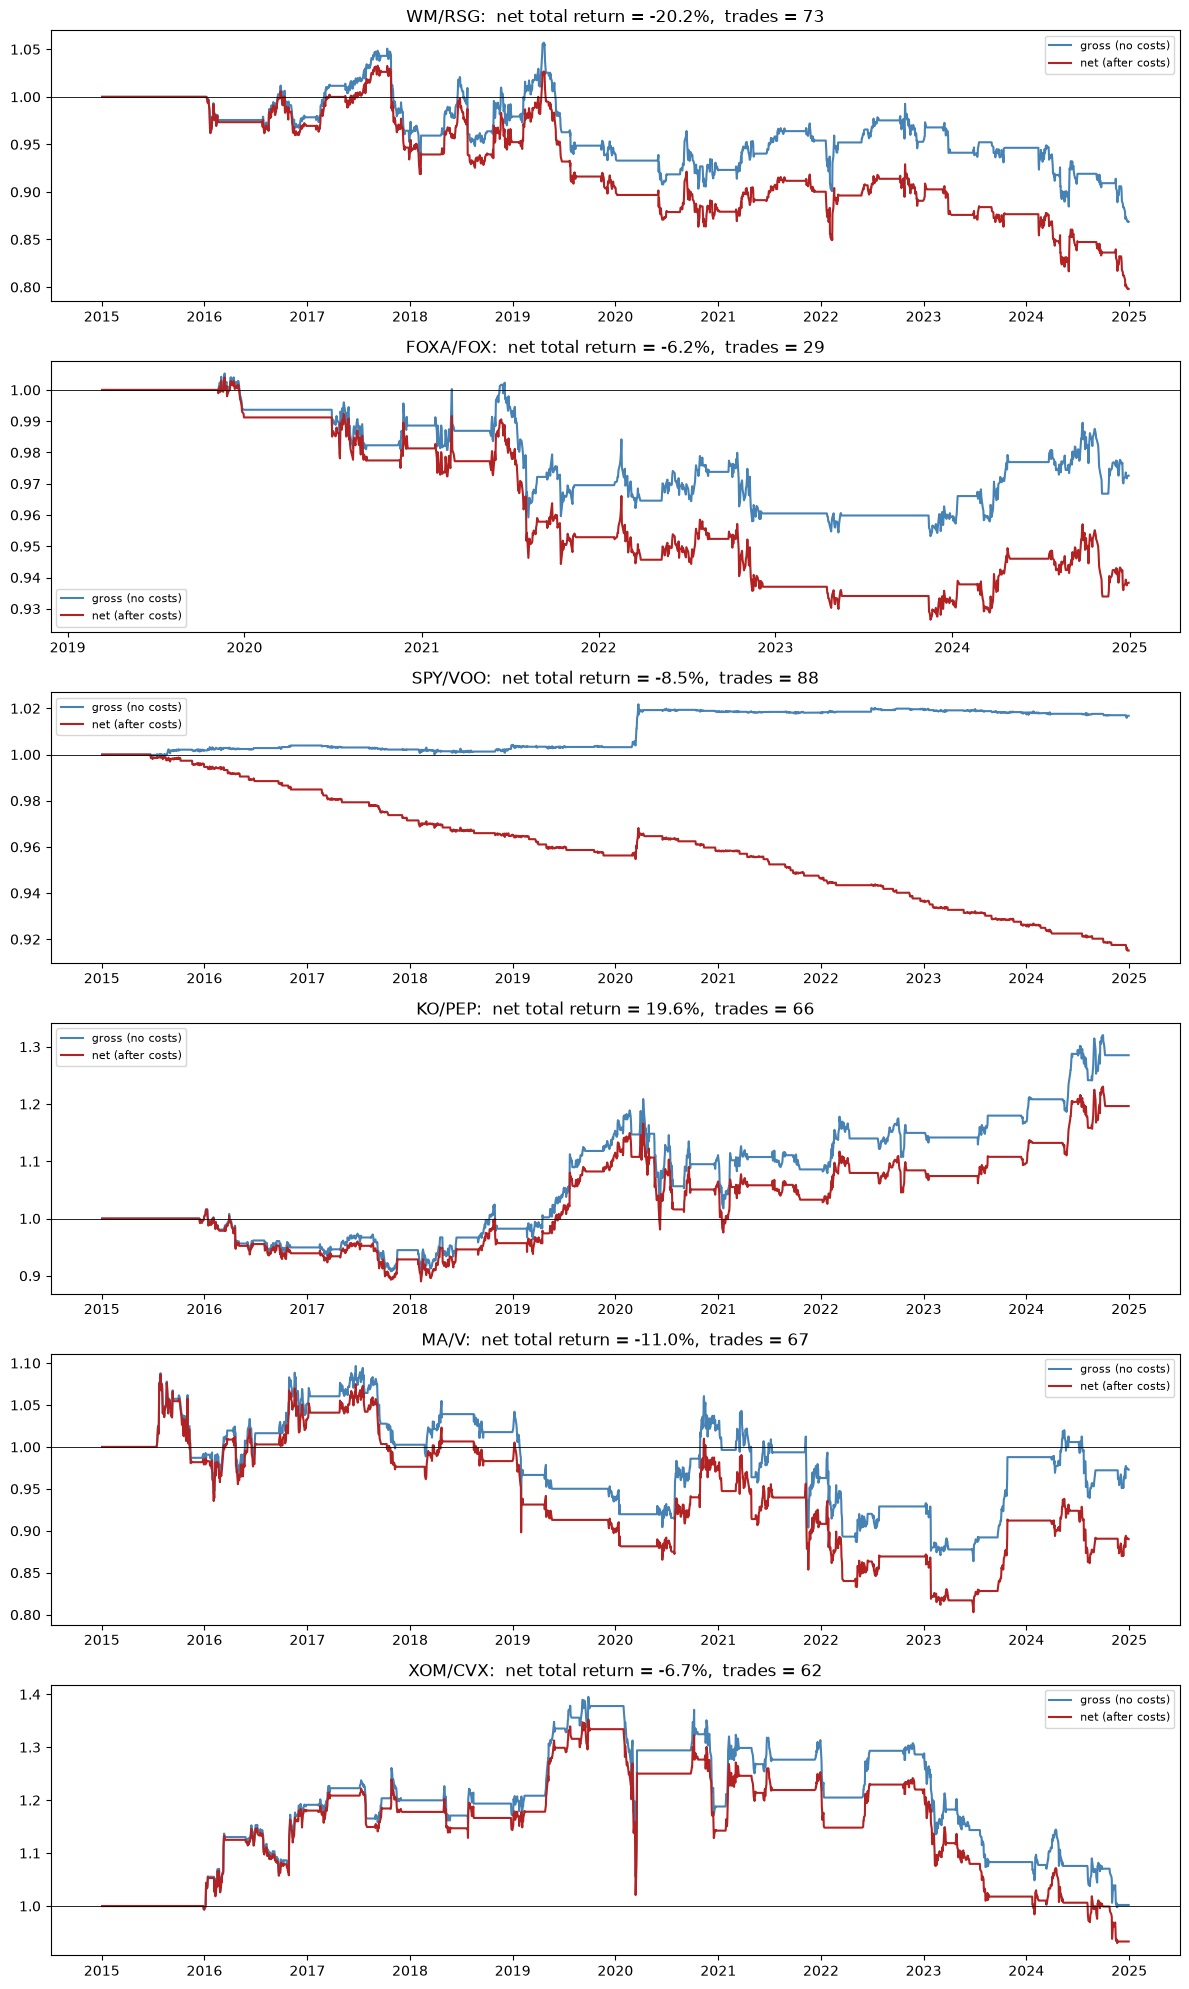

In [48]:
fig, axes = plt.subplots(6, 1, figsize=(12, 20))
for ax, (a, b) in zip(axes, pair_defs):
    name = f"{a}/{b}"
    res = results[name]
    idx = res.equity_curve.index
    ax.plot(idx, (1 + res.gross_returns).cumprod(), label="gross (no costs)", color="steelblue")
    ax.plot(idx, res.equity_curve, label="net (after costs)", color="firebrick")
    ax.axhline(1.0, color="black", lw=0.6)
    ax.set_title(f"{name}:  net total return = "
                 f"{(res.equity_curve.iloc[-1] - 1):.1%},  trades = {res.n_trades}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### SPY/VOO 2020 spike investigation

Gross return, COVID window only:  1.60%
Gross return, full sample:         1.68%
Gross return, full sample EXCLUDING COVID window:
  0.08%


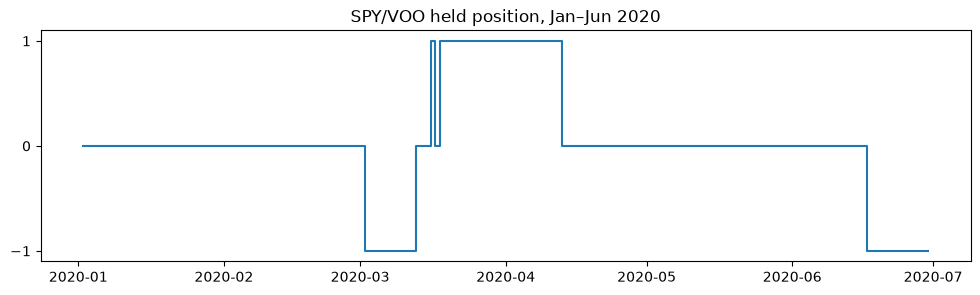

In [49]:
res = results["SPY/VOO"]

# Isolate the COVID window
covid_window = res.returns.loc["2020-02-01":"2020-04-30"]
full_sample = res.returns

print(f"Gross return, COVID window only:  {(1+res.gross_returns.loc['2020-02-01':'2020-04-30']).prod()-1:.2%}")
print(f"Gross return, full sample:         {(1+res.gross_returns).prod()-1:.2%}")
print(f"Gross return, full sample EXCLUDING COVID window:")
outside = res.gross_returns.drop(res.gross_returns.loc["2020-02-01":"2020-04-30"].index)
print(f"  {(1+outside).prod()-1:.2%}")

# Plot the position and z-score during that window to see what fired
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(res.held_positions.loc["2020-01-01":"2020-06-30"], drawstyle="steps-post")
ax.set_title("SPY/VOO held position, Jan–Jun 2020")
ax.set_yticks([-1, 0, 1])
plt.show()

### KO/PEP 2024 spike investigation

Gross return, 2024 only:              9.97%
Gross return, full sample:             28.52%
Gross return, full sample EXCLUDING 2024:
  16.87%


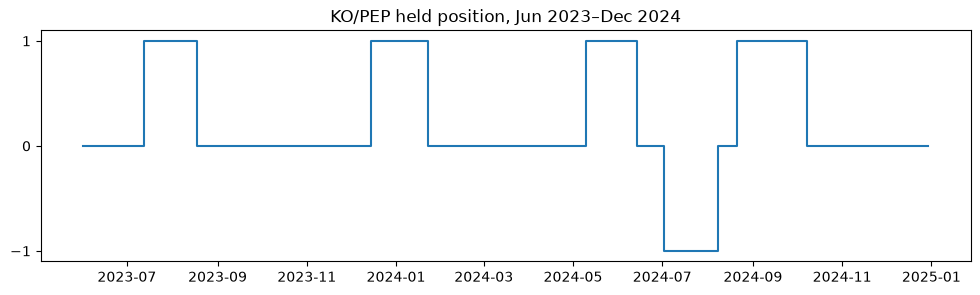

In [50]:
res = results["KO/PEP"]

window_2024 = res.gross_returns.loc["2024-01-01":"2024-12-31"]
outside_2024 = res.gross_returns.drop(window_2024.index)

print(f"Gross return, 2024 only:              {(1+window_2024).prod()-1:.2%}")
print(f"Gross return, full sample:             {(1+res.gross_returns).prod()-1:.2%}")
print(f"Gross return, full sample EXCLUDING 2024:")
print(f"  {(1+outside_2024).prod()-1:.2%}")

# Position/z-score during the breakout, for visual confirmation
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(res.held_positions.loc["2023-06-01":"2024-12-31"], drawstyle="steps-post")
ax.set_title("KO/PEP held position, Jun 2023–Dec 2024")
ax.set_yticks([-1, 0, 1])
plt.show()

### Statis hedge ratio (signal), trailing window sweep

In [51]:
static_signal_results = {}
for a, b in pair_defs:
    name = f"{a}/{b}"
    raw = pairs[name]
    lg = to_log_prices(raw)

    static_hr_val = estimate_hedge_ratio(lg[a], lg[b])
    static_hr = pd.Series(static_hr_val, index=raw.index)

    static_spread = build_spread(lg[a], lg[b], static_hr_val)  # deterministic, no window

    for window in [40, 60, 90, 120]:
        z = rolling_zscore(static_spread, window)  # ONLY the z-score window varies now
        pos = target_positions(z, ENTRY, EXIT)
        res = run_backtest(raw[a], raw[b], pos, static_hr, costs)
        static_signal_results[(name, window)] = res.equity_curve.iloc[-1] - 1

for (name, w), ret in static_signal_results.items():
    print(f"{name:12s} window={w:3d}  net={ret:+.1%}")

WM/RSG       window= 40  net=-10.6%
WM/RSG       window= 60  net=+4.7%
WM/RSG       window= 90  net=+14.7%
WM/RSG       window=120  net=+29.7%
FOXA/FOX     window= 40  net=-8.9%
FOXA/FOX     window= 60  net=-4.6%
FOXA/FOX     window= 90  net=+2.1%
FOXA/FOX     window=120  net=+1.6%
SPY/VOO      window= 40  net=-17.9%
SPY/VOO      window= 60  net=-15.4%
SPY/VOO      window= 90  net=-14.6%
SPY/VOO      window=120  net=-12.9%
KO/PEP       window= 40  net=-16.2%
KO/PEP       window= 60  net=-15.9%
KO/PEP       window= 90  net=-11.7%
KO/PEP       window=120  net=-2.0%
MA/V         window= 40  net=+42.8%
MA/V         window= 60  net=+63.1%
MA/V         window= 90  net=+76.8%
MA/V         window=120  net=+79.3%
XOM/CVX      window= 40  net=-27.5%
XOM/CVX      window= 60  net=-27.5%
XOM/CVX      window= 90  net=+13.8%
XOM/CVX      window=120  net=+48.8%


### Rolling hedge ratio (signal), trailing window sweep

In [52]:
grid = [40, 50, 60, 75, 90, 120]
sweep_results = {}

for a, b in pair_defs:
    name = f"{a}/{b}"
    raw = pairs[name]
    lg = to_log_prices(raw)
    static_hr_val = estimate_hedge_ratio(lg[a], lg[b])
    static_hr = pd.Series(static_hr_val, index=raw.index)

    for window in grid:
        z = rolling_zscore(build_rolling_spread(lg[a], lg[b], window), window)
        pos = target_positions(z, 2.0, 0.5)
        res = run_backtest(raw[a], raw[b], pos, static_hr, costs)
        sweep_results[(name, window)] = res.equity_curve.iloc[-1] - 1

sweep_table = pd.Series(sweep_results).unstack()
print(sweep_table.round(3))
print("\nSign changes across the grid, per pair:")
print(sweep_table.apply(lambda row: (row > 0).nunique() > 1, axis=1))

            40     50     60     75     90     120
FOXA/FOX -0.073 -0.108 -0.062 -0.037 -0.094 -0.007
KO/PEP   -0.065  0.098  0.196  0.156 -0.095 -0.037
MA/V     -0.254 -0.148 -0.110 -0.222 -0.141 -0.303
SPY/VOO  -0.133 -0.110 -0.085 -0.056 -0.051 -0.042
WM/RSG   -0.121 -0.136 -0.202 -0.002  0.110  0.188
XOM/CVX   0.048 -0.138 -0.067 -0.434 -0.188  0.252

Sign changes across the grid, per pair:
FOXA/FOX    False
KO/PEP       True
MA/V        False
SPY/VOO     False
WM/RSG       True
XOM/CVX      True
dtype: bool


In [53]:
diag_rows = []
for a, b in pair_defs:
    name = f"{a}/{b}"
    raw = pairs[name]
    lg = to_log_prices(raw)
    static_hr_val = estimate_hedge_ratio(lg[a], lg[b])
    static_hr = pd.Series(static_hr_val, index=raw.index)
    static_spread = build_spread(lg[a], lg[b], static_hr_val)

    for window in [40, 60, 90, 120]:
        z = rolling_zscore(static_spread, window)
        pos = target_positions(z, 2.0, 0.5)
        res = run_backtest(raw[a], raw[b], pos, static_hr, costs)
        gross_total = (1 + res.gross_returns).prod() - 1
        net_total = res.equity_curve.iloc[-1] - 1
        diag_rows.append({
            "pair": name, "window": window,
            "gross": gross_total, "net": net_total,
            "trades": res.n_trades, "cost_drag": gross_total - net_total,
        })

diag_df = pd.DataFrame(diag_rows)
print("Trade count by window:")
print(diag_df.pivot(index="pair", columns="window", values="trades"))
print("\nGROSS return by window (the key check):")
print(diag_df.pivot(index="pair", columns="window", values="gross").round(3))
print("\nCost drag (gross - net) by window:")
print(diag_df.pivot(index="pair", columns="window", values="cost_drag").round(3))

Trade count by window:
window    40   60   90   120
pair                        
FOXA/FOX   75   48   33   23
KO/PEP    109   81   53   43
MA/V      134   98   76   60
SPY/VOO   218  208  200  186
WM/RSG    108   86   63   53
XOM/CVX   108   71   61   56

GROSS return by window (the key check):
window      40     60     90     120
pair                                
FOXA/FOX  0.001  0.013  0.063  0.045
KO/PEP   -0.054 -0.081 -0.064  0.028
MA/V      0.708  0.860  0.958  0.947
SPY/VOO   0.076  0.096  0.098  0.101
WM/RSG    0.015  0.158  0.235  0.381
XOM/CVX  -0.177 -0.214  0.221  0.586

Cost drag (gross - net) by window:
window      40     60     90     120
pair                                
FOXA/FOX  0.090  0.060  0.042  0.029
KO/PEP    0.107  0.078  0.053  0.048
MA/V      0.280  0.229  0.190  0.154
SPY/VOO   0.255  0.250  0.244  0.230
WM/RSG    0.122  0.111  0.088  0.084
XOM/CVX   0.098  0.062  0.083  0.099
